In [2]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import csv

In [23]:
def make_qtable(qtable):
    file = open(qtable)
    read_file = csv.reader(file)
    data = []
    for rows in read_file:
        data.append(rows)
    file.close()
    qtable_data =[]
    n = len(data[0][0].split())
    for rows in data[1:]:
        str_data = rows[0].split()
        n_row = len(str_data)
        if n_row == n:
            wave = str_data[1]
            ext = str_data[2]
        elif n_row ==n-1:
            check = str_data[1]
            if len(check)>10:
                wave = check[:10]
                ext = check[1][10:21]
            if len(str_data[2]):
                wave = check
                ext = str_data[2][:10]
        elif n_row == n-2:
            wave = rows[0].split()[1][:10]
            ext = rows[0].split()[1][10:21]
        wave_ext=[wave,ext]
        qtable_data.append(wave_ext) 
    headings = data[0][0].split()[1:3]
    df_table = pd.DataFrame(data=qtable_data,columns=headings)
    aeff = data[1][0].split()[0]
    for i in range(2):
        df_table[headings[i]]=pd.to_numeric(df_table[headings[i]])
    aeff=float(aeff)
    print(aeff)
    radius = aeff*2**(-1/3)
    print(radius)
    return df_table

In [25]:
df_10 = make_qtable('qtable_10')
df_10[:10]

0.0126
0.010000626627399657


,wave,Q_ext
0,0.30000,0.097837
1,0.30039,0.098633
2,0.30079,0.099424
3,0.30118,0.100210
4,0.30158,0.100990
5,0.30198,0.101770
6,0.30238,0.102550
7,0.30278,0.103310
8,0.30318,0.104080
9,0.30358,0.104840


In [45]:
df_20=make_qtable('qtable_20')

0.0252
0.020001253254799314


In [63]:
df_30 =make_qtable('qtable_30')

0.0378
0.030001879882198972


In [65]:
df_10 = pd.read_csv('qtable_10',sep='\s+')

In [207]:
df_40 = make_qtable('qtable_40')
df_40[df_40['wave']>=0.45].values.max()

0.0504
0.04000250650959863


4.0669

1.1113 2.2002 3.1846 4.0669
The dipole spacing is fixed d = 1.5 nm and radii are varied as 10nm, 20 nm, 30 nm


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


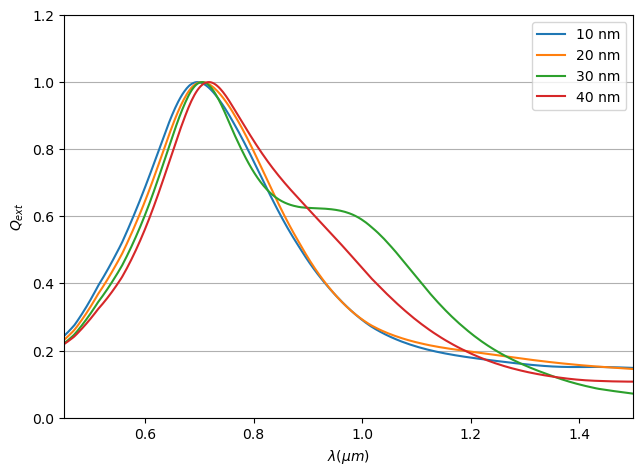

In [221]:
max_10 = df_10['Q_ext'].values.max()
max_20 = df_20['Q_ext'].values.max()
max_30 = df_30['Q_ext'].values.max()
max_40 =df_40[df_40['wave']>=0.45].values.max()
print(max_10,max_20,max_30,max_40)
print('The dipole spacing is fixed d = 1.5 nm and radii are varied as 10nm, 20 nm, 30 nm')
plt.plot(df_10['wave'].values,df_10['Q_ext']/max_10,label='10 nm')
plt.plot(df_20['wave'].values,df_20['Q_ext'].values/max_20,label='20 nm')
plt.plot(df_30['wave'].values,df_30['Q_ext'].values/max_30,label='30 nm')
plt.plot(df_40['wave'].values,df_40['Q_ext'].values/max_40,label='40 nm')
plt.xlabel('$\lambda(\mu m)$')
plt.ylabel('$Q_{ext}$')
plt.legend()
plt.tight_layout()
ax = plt.gca()
ax.yaxis.grid()
plt.xlim(0.45,1.5)
plt.ylim(0,1.2)
#plt.title(f'2 Cs spheres with different radii with sep= 0d') 
plt.savefig('radius_var.eps')
plt.show()

In [246]:
df_col = [df_10,df_20,df_30,df_40]
max_val =[max_10,max_20,max_30,max_40]
for i in range(len(df_col)):
    df = df_col[i]
    print(df[df['Q_ext']==max_val[i]]['wave'].values)

[0.69722]
[0.70478]
[0.70478]
[0.71864]


In [262]:
df_sep_1d = make_qtable('qtable_sep_1d')
df_sep_2d = make_qtable('qtable_sep_2d')
df_sep_3d = make_qtable('qtable_sep_3d')
df_sep_4d = make_qtable('qtable_sep_4d')
df_sep_12d = make_qtable('qtable_sep_4d')

0.0126
0.010000626627399657
0.0126
0.010000626627399657
0.0126
0.010000626627399657
0.0126
0.010000626627399657
0.0126
0.010000626627399657


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


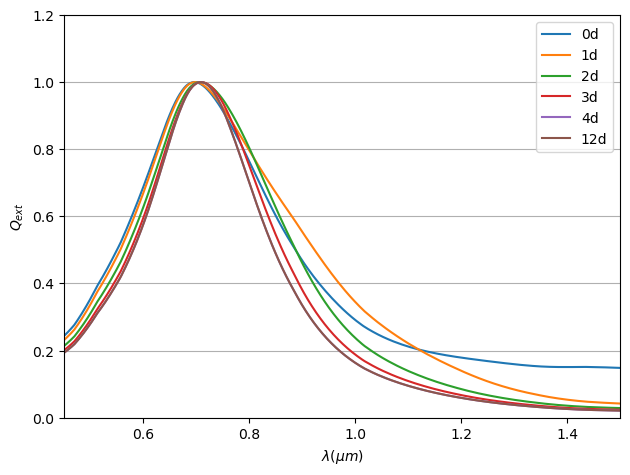

In [287]:
max_1d = df_sep_1d['Q_ext'].values.max()
max_2d = df_sep_2d['Q_ext'].values.max()
max_3d = df_sep_3d['Q_ext'].values.max()
max_4d = df_sep_4d['Q_ext'].values.max()
max_12d = df_sep_12d['Q_ext'].values.max()
plt.plot(df_10['wave'].values,df_10['Q_ext']/max_10,label='0d')
plt.plot(df_sep_1d['wave'],df_sep_1d['Q_ext']/max_1d,label='1d')
plt.plot(df_sep_2d['wave'],df_sep_2d['Q_ext']/max_2d,label='2d')
plt.plot(df_sep_3d['wave'],df_sep_3d['Q_ext']/max_3d,label='3d')
plt.plot(df_sep_4d['wave'],df_sep_4d['Q_ext']/max_4d,label='4d')
plt.plot(df_sep_4d['wave'],df_sep_4d['Q_ext']/max_12d,label='12d')
plt.xlabel('$\lambda(\mu m)$')
plt.ylabel('$Q_{ext}$')
plt.legend()
plt.tight_layout()
ax = plt.gca()
ax.yaxis.grid()
plt.xlim(0.45,1.5)
plt.ylim(0,1.2)
#plt.title('2 Cs spheres with 10 nm radius with different seperations') 
plt.savefig('separation.eps')
plt.show()

In [295]:
df_col = [df_sep_1d,df_sep_2d,df_sep_3d,df_sep_4d,df_sep_12d]
max_val =[max_1d,max_2d,max_3d,max_4d,max_12d]
wave_peak =[]
for i in range(len(df_col)):
    df = df_col[i]
    wave_peak.append(df[df['Q_ext']==max_val[i]]['wave'].values[0])
wave_peak =np.array(wave_peak)
wave_peak.mean()*1000

706.114

In [281]:
df_10_new = make_qtable('qtable')

0.0252
0.020001253254799314


(0.4, 1.45)

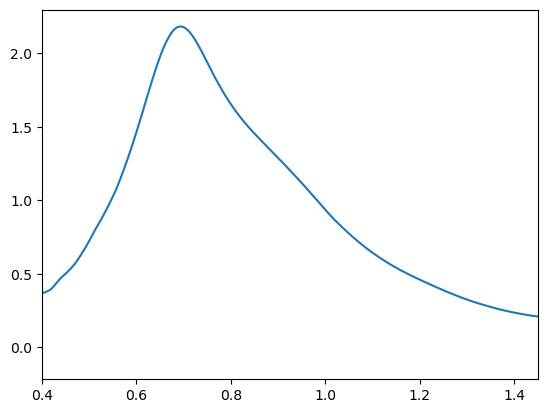

In [285]:
plt.plot(df_10_new['wave'],df_10_new['Q_ext'])
plt.xlim(0.4,1.45)